# Классификация исхода при первичном билиарном холангите

Данные: [Mayo Clinic PBC](https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/survival/pbc.csv)
(Fleming & Harrington, 1991) — 418 пациентов рандомизированного испытания D-пеницилламина.

Таргет `Status`: **C** — наблюдение прекращено, **CL** — пересадка печени, **D** — смерть.
Метрика — **multi-class log loss** (меньше лучше), рядом смотрим accuracy и balanced accuracy.

Главный вывод разбора: признак `N_Days` — это **утечка таргета**, и его приходится выбросить,
хотя метрика от этого ухудшается. Ниже показано, почему.

Логика вынесена в `src/`, ноутбук — разбор по шагам.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "src"))

from data import load
from train import (
    CLASSES, SEEDS, baseline_oof, build_features, cross_validate, metrics_frame,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 130)

## Данные

In [2]:
df = load()
print(df.shape)
df.head()

(418, 20)


,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
0,1,400,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0,D
1,2,4500,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0,C
2,3,1012,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0,D
3,4,1925,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0,D
4,5,1504,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0,CL


## Разведочный анализ

Два обстоятельства определяют всё дальнейшее: сильный дисбаланс классов и настоящие пропуски.

In [3]:
counts = df["Status"].value_counts()
pd.DataFrame({"пациентов": counts, "доля, %": (counts / len(df) * 100).round(1)})

,пациентов,"доля, %"
Status,,
C,232,55.5
D,161,38.5
CL,25,6.0


In [4]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pd.DataFrame({"пропусков": missing, "доля, %": (missing / len(df) * 100).round(1)})

,пропусков,"доля, %"
Tryglicerides,136,32.5
Cholesterol,134,32.1
Copper,108,25.8
Drug,106,25.4
Spiders,106,25.4
Hepatomegaly,106,25.4
Ascites,106,25.4
Alk_Phos,106,25.4
SGOT,106,25.4
Platelets,11,2.6


Пропуски сосредоточены в лабораторных показателях, и это не случайность: 106 из 418 пациентов
не входили в рандомизированное испытание, поэтому у них нет ни назначенного препарата, ни части
анализов. Сам факт пропуска несёт информацию, так что заполнять его средним не нужно —
и XGBoost, и CatBoost умеют работать с NaN и выбирают направление ветвления для них сами.

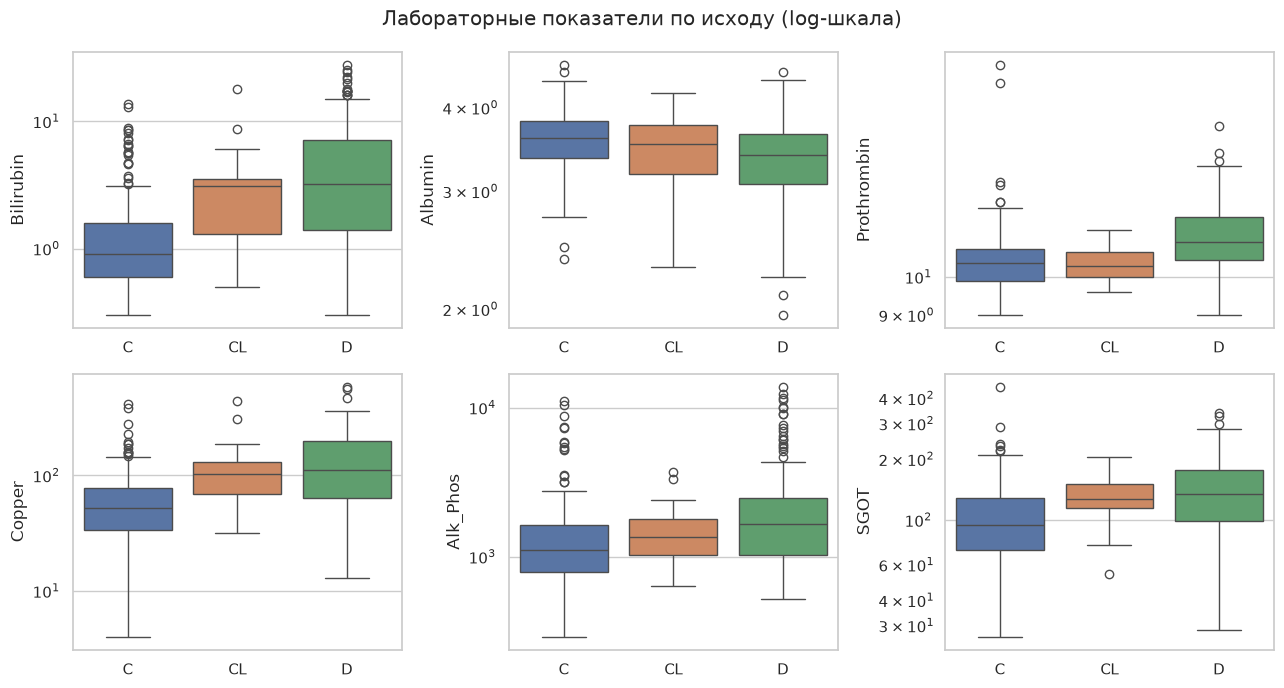

In [5]:
labs = ["Bilirubin", "Albumin", "Prothrombin", "Copper", "Alk_Phos", "SGOT"]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.ravel(), labs):
    sns.boxplot(data=df, x="Status", y=col, order=CLASSES, hue="Status",
                hue_order=CLASSES, legend=False, ax=ax)
    ax.set_yscale("log")
    ax.set_xlabel("")
fig.suptitle("Лабораторные показатели по исходу (log-шкала)")
fig.tight_layout()
plt.show()

Картина клинически ожидаемая: у умерших пациентов выше билирубин, протромбиновое время и медь,
ниже альбумин. То есть сигнал в данных есть, и он совпадает с известными прогностическими
факторами модели Mayo.

## Утечка таргета через N_Days

`N_Days` — это число дней от включения в исследование до наступления события: смерти, пересадки
или момента закрытия исследования. То есть это **время до события**, а `Status` — **тип события**.
Вместе они образуют исход целиком, поэтому предсказывать одно по другому — значит подглядывать
в ответ.

In [6]:
df.groupby("Status")["N_Days"].describe()[["count", "min", "25%", "50%", "75%", "max"]].round(0)

,count,min,25%,50%,75%,max
Status,,,,,,
C,232.0,691.0,1456.0,2186.0,2980.0,4795.0
CL,25.0,533.0,901.0,1435.0,2241.0,3092.0
D,161.0,41.0,597.0,1083.0,2071.0,4191.0


In [7]:
quartile = pd.qcut(df["N_Days"], 4, labels=["Q1 (короткое)", "Q2", "Q3", "Q4 (длинное)"])
(pd.crosstab(quartile, df["Status"], normalize="index")[CLASSES] * 100).round(1)

Status,C,CL,D
N_Days,,,
Q1 (короткое),13.3,9.5,77.1
Q2,63.5,6.7,29.8
Q3,69.2,5.8,25.0
Q4 (длинное),76.2,1.9,21.9


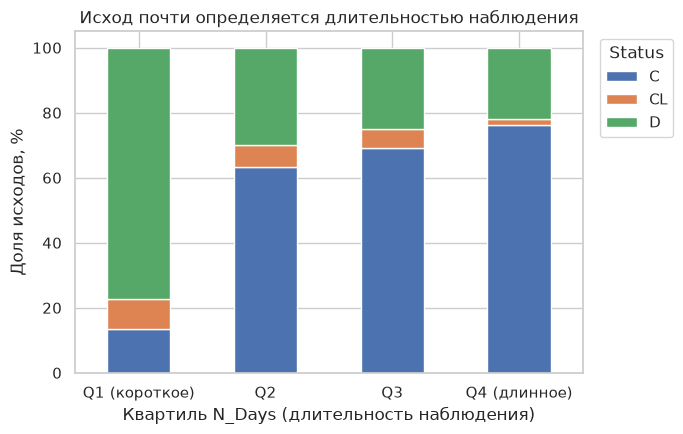

In [8]:
share = pd.crosstab(quartile, df["Status"], normalize="index")[CLASSES] * 100
fig, ax = plt.subplots(figsize=(7, 4.5))
share.plot(kind="bar", stacked=True, ax=ax, rot=0,
           color=["#4c72b0", "#dd8452", "#55a868"])
ax.set_xlabel("Квартиль N_Days (длительность наблюдения)")
ax.set_ylabel("Доля исходов, %")
ax.set_title("Исход почти определяется длительностью наблюдения")
ax.legend(title="Status", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

In [9]:
c_min = df.loc[df["Status"] == "C", "N_Days"].min()
d_min = df.loc[df["Status"] == "D", "N_Days"].min()
print(f"минимальный N_Days у цензурированных (C): {c_min:.0f} дней")
print(f"минимальный N_Days у умерших (D):         {d_min:.0f} дней")
print()
print(f"доля C при N_Days < 1000: {(df.loc[df.N_Days < 1000, 'Status'] == 'C').mean():.1%}")
print(f"доля C при N_Days > 3000: {(df.loc[df.N_Days > 3000, 'Status'] == 'C').mean():.1%}")

минимальный N_Days у цензурированных (C): 691 дней
минимальный N_Days у умерших (D):         41 дней

доля C при N_Days < 1000: 8.9%
доля C при N_Days > 3000: 73.7%


Вот в чём проблема. Цензурирование наступает в момент закрытия исследования, поэтому у пациента
со статусом `C` наблюдение длинное **по построению** — минимум 691 день. Смерти же начинаются
с 41 дня. Значит правило «`N_Days` < 691 ⟹ пациент точно не `C`» выполняется детерминированно,
и модель его находит.

Это артефакт дизайна исследования, а не медицинская закономерность. На момент, когда врач
реально хочет получить прогноз — при постановке диагноза — `N_Days` неизвестен, потому что
событие ещё не наступило. Оставить его в признаках значит получить красивую метрику и
бесполезную модель.

In [10]:
X_only, y = build_features(df, with_ndays=True)
oof_only = cross_validate("cat", False, X_only[["N_Days"]], y, n_repeats=3)
metrics_frame(y, oof_only).mean().round(4)

  повтор seed=42: log loss = 0.7209


  повтор seed=43: log loss = 0.7249


  повтор seed=44: log loss = 0.7256


log loss             0.7238
accuracy             0.7081
balanced accuracy    0.4766
macro F1             0.4656
dtype: float64

Один `N_Days`, без единого анализа крови, даёт accuracy около 0.70 против 0.555 у тривиального
предсказания мажоритарного класса. Дальше он исключён: `build_features` убирает его по умолчанию,
а флаг `--with-ndays` оставлен только чтобы воспроизвести постановку как на Kaggle для сравнения.

## Подготовка признаков

Все категории здесь либо бинарные, либо упорядоченные (`Edema`: нет < слабый < есть), поэтому
целочисленные коды не навязывают ложного порядка. Словари кодировки заданы явно и зафиксированы
в `src/train.py` — это важно, потому что `pd.factorize`, применённый к train и test по
отдельности, выдал бы разные коды для одних и тех же категорий.

In [11]:
X, y = build_features(df, with_ndays=False)
print(f"{X.shape[0]} пациентов, {X.shape[1]} признаков (N_Days исключён)")
print(f"доля пропусков: {X.isna().to_numpy().mean():.1%}")
X.head()

418 пациентов, 17 признаков (N_Days исключён)
доля пропусков: 14.5%


,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,0.0,21464.0,0.0,1.0,1.0,1.0,2.0,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,0.0,20617.0,0.0,0.0,1.0,1.0,0.0,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,0.0,25594.0,1.0,0.0,0.0,0.0,1.0,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,0.0,19994.0,0.0,0.0,1.0,1.0,1.0,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,1.0,13918.0,0.0,0.0,1.0,1.0,0.0,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


## Валидация

Датасет маленький — 418 строк, из них всего 25 в классе `CL`. Одиночное разбиение 80/20 дало бы
5 примеров редкого класса в валидации, и метрика скакала бы от сида. Поэтому берём
стратифицированную 5-fold CV, повторяем её с пятью разными сидами и смотрим на разброс:
без него невозможно отличить настоящее улучшение от шума.

In [12]:
oof_cat = cross_validate("cat", False, X, y, n_repeats=len(SEEDS))

  повтор seed=42: log loss = 0.6415


  повтор seed=43: log loss = 0.6303


  повтор seed=44: log loss = 0.6572


  повтор seed=45: log loss = 0.6234


  повтор seed=46: log loss = 0.6255


In [13]:
frame = metrics_frame(y, oof_cat)
summary = pd.DataFrame({"среднее": frame.mean(), "sd": frame.std()}).round(4)
summary["baseline"] = metrics_frame(y, baseline_oof(y)).mean().round(4)
summary

,среднее,sd,baseline
log loss,0.6356,0.0140,0.8627
accuracy,0.7416,0.0066,0.5550
balanced accuracy,0.5195,0.0045,0.3333
macro F1,0.5082,0.0088,0.2379


### Сравнение постановок и моделей

Каждая конфигурация оценена одинаково — 5 повторов стратифицированной 5-fold CV.

In [14]:
rows = []
for with_nd in (False, True):
    Xc, yc = build_features(df, with_ndays=with_nd)
    for model in ("cat", "xgb"):
        for balanced in (False, True):
            if with_nd and balanced:
                continue
            oofs = cross_validate(model, balanced, Xc, yc, n_repeats=len(SEEDS))
            m = metrics_frame(yc, oofs).mean()
            rows.append({
                "постановка": "с N_Days" if with_nd else "без N_Days",
                "модель": model + (" + balanced" if balanced else ""),
                "log loss": round(m["log loss"], 4),
                "accuracy": round(m["accuracy"], 4),
                "balanced acc": round(m["balanced accuracy"], 4),
                "macro F1": round(m["macro F1"], 4),
            })

comparison = pd.DataFrame(rows).sort_values(["постановка", "log loss"])
comparison.reset_index(drop=True)

  повтор seed=42: log loss = 0.6415


  повтор seed=43: log loss = 0.6303


  повтор seed=44: log loss = 0.6572


  повтор seed=45: log loss = 0.6234


  повтор seed=46: log loss = 0.6255


...

  повтор seed=43: log loss = 0.6179


  повтор seed=44: log loss = 0.6366


  повтор seed=45: log loss = 0.6136


  повтор seed=46: log loss = 0.6021


,постановка,модель,log loss,accuracy,balanced acc,macro F1
0,без N_Days,cat,0.6356,0.7416,0.5195,0.5082
1,без N_Days,xgb,0.6843,0.7206,0.5418,0.5560
2,без N_Days,cat + balanced,0.6934,0.7043,0.5994,0.5805
3,без N_Days,xgb + balanced,0.7180,0.6995,0.5625,0.5612
4,с N_Days,cat,0.5785,0.7632,0.5299,0.5174
5,с N_Days,xgb,0.6197,0.7517,0.5669,0.5812


Из таблицы видно три вещи. Переход с XGBoost на CatBoost даёт настоящий выигрыш — примерно
0.045 log loss при разбросе 0.014, то есть свыше трёх стандартных отклонений. Исключение
`N_Days` стоит примерно 0.06 log loss, и это цена корректности. А балансировка классов
улучшает balanced accuracy и macro F1, но портит log loss: она сдвигает вероятности,
и калибровка страдает.

              precision    recall  f1-score   support

           C       0.76      0.85      0.81       232
          CL       0.00      0.00      0.00        25
           D       0.73      0.72      0.72       161

    accuracy                           0.75       418
   macro avg       0.50      0.52      0.51       418
weighted avg       0.71      0.75      0.73       418



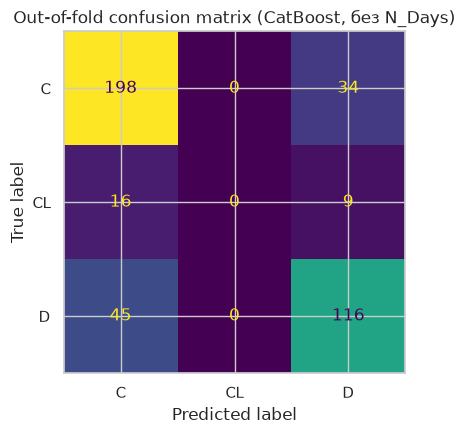

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

print(classification_report(y, oof_cat[0].argmax(axis=1), target_names=CLASSES,
                            zero_division=0))

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y, oof_cat[0].argmax(axis=1), display_labels=CLASSES, ax=ax, colorbar=False,
)
ax.set_title("Out-of-fold confusion matrix (CatBoost, без N_Days)")
fig.tight_layout()
plt.show()

Класс `CL` не распознаётся вовсе: 25 примеров на три класса — слишком мало, и по лабораторным
показателям пересадка печени почти не отличается от продолжения наблюдения. Если этот класс
важен сам по себе, нужен флаг `--balanced`: он поднимает balanced accuracy с 0.52 до 0.60,
но ухудшает log loss с 0.636 до 0.693. Выбор зависит от того, что нужнее — калиброванные
вероятности или внимание к редкому классу.

## Важность признаков

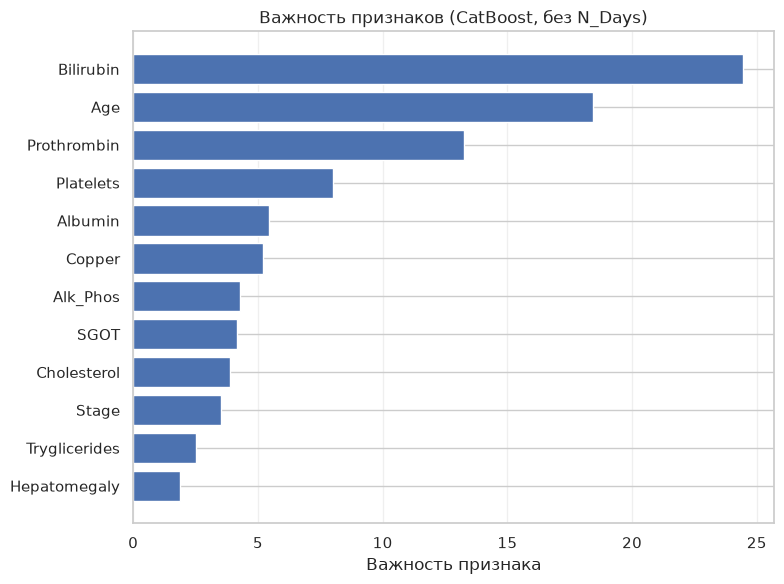

In [16]:
from train import make_model

model = make_model("cat", False, SEEDS[0]).fit(X, y)
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values().tail(12)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance.index, importance.to_numpy())
ax.set_xlabel("Важность признака")
ax.set_title("Важность признаков (CatBoost, без N_Days)")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

## Что проверено и не помогло

Чтобы не выдавать шум за улучшение, каждый вариант оценивался теми же 5 повторами CV.
При разбросе около 0.014 log loss всё, что меняет метрику слабее, чем на 0.03, считаем шумом.

Все числа ниже — честная постановка без `N_Days`, те же 5 повторов CV. При разбросе около
0.014 log loss всё, что меняет метрику слабее, чем на 0.03, считаем шумом.

| Что пробовали | log loss | вывод |
|---|---|---|
| XGBoost на 17 исходных признаках | 0.6843 ± 0.0146 | опорная точка (версия V1) |
| + log-трансформы и индекс Mayo | 0.6872 ± 0.0126 | без эффекта: деревьям монотонные преобразования не нужны |
| + клинические отношения (билирубин/альбумин, APRI) | 0.6998 ± 0.0151 | хуже, лишняя размерность на 418 строках |
| LightGBM вместо XGBoost | 0.7901 ± 0.0197 | заметно хуже на таком объёме |
| **CatBoost вместо XGBoost** | **0.6405 ± 0.0136** | единственный реальный выигрыш |
| CatBoost с подобранными параметрами | **0.6356 ± 0.0140** | итоговая конфигурация |
| CatBoost глубже (depth 6) | 0.6614 ± 0.0216 | переобучение |
| смесь CatBoost + XGBoost | 0.6404 | ничего сверх одного CatBoost |

Практический вывод: на датасете такого размера выигрыш дала только смена модели, а
усложнение признаков стабильно не оправдывалось.

## Выводы

1. `N_Days` — утечка таргета: это время до события, недоступное на момент прогноза. Исключён,
   ценой примерно 0.06 log loss.
2. В честной постановке CatBoost даёт log loss **0.6356 ± 0.0140** против **0.8627** у baseline
   и **0.6843** у XGBoost из первой версии.
3. Самые сильные признаки — билирубин, возраст, протромбиновое время и тромбоциты. Первые три
   плюс альбумин на пятом месте дают четыре из пяти составляющих прогностического индекса Mayo
   для ПБХ, то есть модель опирается на клинически осмысленные величины.
4. Редкий класс `CL` остаётся нераспознанным; на 25 примерах это не лечится ни подбором
   гиперпараметров, ни балансировкой без потерь в калибровке.